# Setting up the pg database with docker
```bash
# 1. Install and run PostgreSQL
docker run --name prototyping-pg-1 \
  -e POSTGRES_PASSWORD=mypassword \
  -e POSTGRES_USER=testuser \
  -e POSTGRES_DB=testdb \
  -p 5432:5432 \
  -d postgres:15

```

In [1]:
"""
Option 1: Building Distributions with PostgreSQL
This notebook demonstrates computing distributions directly in PostgreSQL
"""

import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from utils import DB_PARAMS, insert_n_rows


In [2]:
# Insert 1 million rows into PostgreSQL
insert_n_rows(1_000_000)

Creating table and inserting 1,000,000 rows...
✓ Successfully inserted 1,000,000 rows


In [ ]:

# Database connection parameters


def get_connection():
    """Create database connection"""
    return psycopg2.connect(**DB_PARAMS)

# ============================================================================
# 1. SETUP: Create sample table with a billion points (simulated)
# ============================================================================

def create_sample_table():
    """Create a sample table - in reality you'd use your existing table"""
    conn = get_connection()
    cur = conn.cursor()
    
    # For demo purposes, we'll create a smaller table
    # In production, replace 'sample_data' with your actual table name
    cur.execute("""
        DROP TABLE IF EXISTS sample_data;
        CREATE TABLE sample_data (
            id SERIAL PRIMARY KEY,
            value DOUBLE PRECISION,
            category VARCHAR(50),
            timestamp TIMESTAMP
        );
    """)
    
    # Generate sample data (you'd skip this for existing data)
    print("Generating sample data...")
    cur.execute("""
        INSERT INTO sample_data (value, category, timestamp)
        SELECT 
            random() * 100 + (random() * 20 - 10) as value,
            CASE WHEN random() < 0.5 THEN 'A' ELSE 'B' END as category,
            NOW() - (random() * INTERVAL '365 days') as timestamp
        FROM generate_series(1, 1000000);  -- Use 1 billion in production
    """)
    
    # Create index for performance
    cur.execute("CREATE INDEX idx_value ON sample_data(value);")
    cur.execute("ANALYZE sample_data;")
    
    conn.commit()
    cur.close()
    conn.close()
    print("Sample table created and indexed")

# ============================================================================
# 2. BASIC STATISTICS
# ============================================================================

def compute_basic_stats():
    """Compute basic statistical measures"""
    conn = get_connection()
    
    query = """
        SELECT 
            COUNT(*) as count,
            MIN(value) as min_val,
            MAX(value) as max_val,
            AVG(value) as mean,
            STDDEV(value) as stddev,
            VARIANCE(value) as variance
        FROM sample_data;
    """
    
    start = datetime.now()
    df = pd.read_sql(query, conn)
    elapsed = (datetime.now() - start).total_seconds()
    
    conn.close()
    
    print(f"Basic Statistics (computed in {elapsed:.2f} seconds):")
    print(df.to_string(index=False))
    return df

# ============================================================================
# 3. HISTOGRAM COMPUTATION
# ============================================================================

def compute_histogram(num_bins=100):
    """Compute histogram using WIDTH_BUCKET"""
    conn = get_connection()
    
    # First get min/max for bucket boundaries
    minmax_query = "SELECT MIN(value) as min_val, MAX(value) as max_val FROM sample_data;"
    minmax = pd.read_sql(minmax_query, conn)
    min_val = minmax['min_val'][0]
    max_val = minmax['max_val'][0]
    
    # Compute histogram
    query = f"""
        SELECT 
            WIDTH_BUCKET(value, {min_val}, {max_val}, {num_bins}) as bucket,
            COUNT(*) as frequency,
            MIN(value) as bucket_min,
            MAX(value) as bucket_max
        FROM sample_data
        GROUP BY bucket
        ORDER BY bucket;
    """
    
    start = datetime.now()
    df = pd.read_sql(query, conn)
    elapsed = (datetime.now() - start).total_seconds()
    
    conn.close()
    
    print(f"\nHistogram with {num_bins} bins (computed in {elapsed:.2f} seconds)")
    print(f"Sample of bins:\n{df.head(10)}")
    
    # Plot
    plt.figure(figsize=(12, 6))
    plt.bar(df['bucket'], df['frequency'], width=0.8)
    plt.xlabel('Bin')
    plt.ylabel('Frequency')
    plt.title(f'Distribution Histogram ({num_bins} bins)')
    plt.tight_layout()
    plt.savefig('histogram_postgres.png', dpi=150)
    print("Histogram saved to histogram_postgres.png")
    
    return df

In [4]:
%%time
compute_basic_stats()

Basic Statistics (computed in 0.04 seconds):
  count   min_val   max_val      mean    stddev   variance
1000000 20.046073 79.953318 50.029243 12.247206 149.994062
CPU times: user 6.26 ms, sys: 2.74 ms, total: 8.99 ms
Wall time: 47.6 ms


/var/folders/x3/9cwlchw11ds16sk0nbp6h8kr0000gn/T/ipykernel_22721/810524116.py:69: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,count,min_val,max_val,mean,stddev,variance
0,1000000,20.046073,79.953318,50.029243,12.247206,149.994062


/var/folders/x3/9cwlchw11ds16sk0nbp6h8kr0000gn/T/ipykernel_22721/810524116.py:88: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  minmax = pd.read_sql(minmax_query, conn)
/var/folders/x3/9cwlchw11ds16sk0nbp6h8kr0000gn/T/ipykernel_22721/810524116.py:105: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)



Histogram with 100 bins (computed in 0.18 seconds)
Sample of bins:
   bucket  frequency  bucket_min  bucket_max
0       1        238   20.046073   20.643471
1       2        624   20.645884   21.243146
2       3       1022   21.244891   21.842384
3       4       1448   21.843813   22.442076
4       5       1788   22.442416   23.040412
5       6       2175   23.042104   23.639796
6       7       2674   23.640977   24.239009
7       8       2925   24.239605   24.838643
8       9       3435   24.838671   25.437493
9      10       3786   25.437898   26.036646
Histogram saved to histogram_postgres.png


,bucket,frequency,bucket_min,bucket_max
0,1,238,20.046073,20.643471
1,2,624,20.645884,21.243146
2,3,1022,21.244891,21.842384
3,4,1448,21.843813,22.442076
4,5,1788,22.442416,23.040412
...,...,...,...,...
96,97,1457,77.557462,78.155339
97,98,998,78.157232,78.753375
98,99,610,78.755418,79.350730
99,100,228,79.356824,79.952478


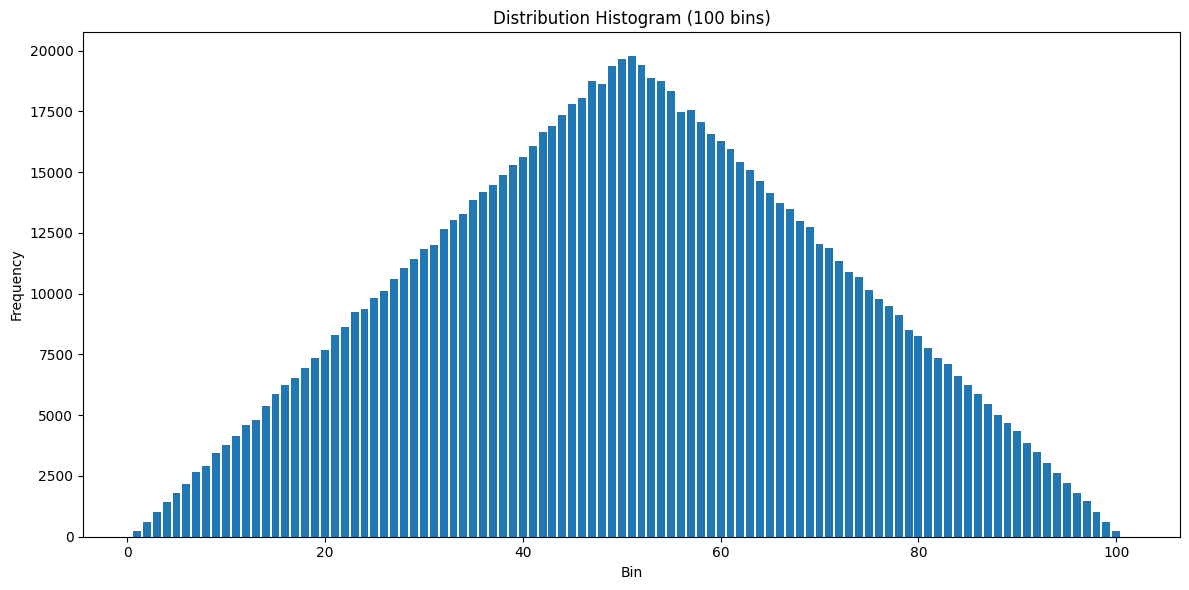

In [ ]:
compute_histogram(num_bins=100)